# RockMetal: Rocky/Icy/Metal Planet Interior Structure

This notebook is a Python translation of the Fortran subroutine `RockMetal`,
which computes the radius of a three-layer planet (Fe core, MgSiO3 mantle,
H2O ice/water shell) given its mass and bulk composition.

**Physics:**
- Each layer follows a third-order **Birch–Murnaghan equation of state (EOS)**,
  relating pressure to density.
- The planet is integrated in mass shells from the surface (P = 0) down to the
  center, enforcing **hydrostatic equilibrium** (dP/dr = −G M(r) ρ / r²) at each
  step.
- Because the total radius isn't known in advance, the whole integration is
  wrapped in a **bisection search on Rp**: guess a radius, integrate inward: if
  you run out of radius before using up all the mass, the guess was too small
  (raise `Rmin`); if you reach the center successfully, the guess was
  sufficient (lower `Rmax`). Iterate until `Rmax - Rmin` converges.

**References for the material EOS parameters:**
- H2O ice VII: Fei, Mao & Hemley (1993), *J. Chem. Phys.* 99, 5369
- MgSiO3 (mantle): Stixrude & Lithgow-Bertelloni (2005), *GJI* 162, 610
- Fe (core): Dewaele et al. (2006), *PRL* 97, 215504


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


## Equation of state

`EoS(P, K0, K0t, rho0)` solves the third-order Birch–Murnaghan EOS for the
density `rho` that produces a given pressure `P`, using simple bisection
(the same fixed-tolerance bisection as the original Fortran `EoS` function).

- `K0`   : bulk modulus at the reference (zero-pressure) state [GPa]
- `K0t`  : pressure derivative of the bulk modulus, dK0/dP
- `rho0` : reference density [g/cm^3]
- returns `rho` in [g/cm^3]


In [2]:
def EoS(P, K0, K0t, rho0):
    """
    Third-order Birch-Murnaghan equation of state, solved for density
    at a given pressure P via bisection.

    P    : pressure [Pa]
    K0   : bulk modulus at reference state [GPa]
    K0t  : pressure derivative of bulk modulus, dK0/dP
    rho0 : reference (zero-pressure) density [g/cm^3]

    Returns density rho [g/cm^3]
    """
    rhomin = 0.5 * rho0
    rhomax = 5.0 * rho0

    eps = 1.0
    rho = rhomin
    while eps > 1e-3:
        rho = (rhomin + rhomax) / 2.0
        f = rho / rho0
        P0 = (3.0 * K0 / 2.0) * (f**(7.0/3.0) - f**(5.0/3.0)) * \
             (1.0 - 3.0 * (4.0 - K0t) * (f**(2.0/3.0) - 1.0) / 4.0)
        P0 = P0 * 1e9  # GPa -> Pa
        if P0 > P:
            rhomax = rho
        else:
            rhomin = rho
        eps = (rhomax - rhomin) / (rhomax + rhomin)
    return rho


## Layered planet structure integration

`rock_metal(f_core, f_h2o, Mp)` mirrors the original Fortran subroutine line
for line:

- Layer order (outside in): **H2O ice → MgSiO3 mantle → Fe core**
- `f_h2o`: water/ice mass fraction of the whole planet
- `f_core`: Fe mass fraction of the *non-ice* remainder (so the mantle mass
  fraction is `(1 - f_h2o) * (1 - f_core)` and the core is
  `(1 - f_h2o) * f_core`)
- `Mp`: planet mass in Earth masses

Each layer is split into `nr = 100` mass shells. Within a shell, the local
density is evaluated from the current pressure via `EoS`, used to shrink the
radius by the shell's mass, and then the pressure is stepped using the
discretized hydrostatic equilibrium equation. If a shell can't fit within the
remaining radius, the outer bisection bracket (`Rmin`) is pushed up; if the
integration reaches the center successfully, the bracket (`Rmax`) is pulled
down. This continues until the bracket has converged to 0.1%.


In [3]:
def rock_metal(f_core, f_h2o, Mp):
    """
    Compute the radius of a rocky/icy/metal planet from its mass and
    bulk composition, integrating hydrostatic equilibrium layer by
    layer using the Birch-Murnaghan EOS.

    f_core : core (Fe) mass fraction of the non-ice material
    f_h2o  : water/ice mass fraction of the whole planet
    Mp     : planet mass [Earth masses]

    Returns Rp : planet radius [Earth radii]
    """
    nr = 100  # radial integration steps per layer

    G = 6.67408e-11        # m3 kg-1 s-2
    Mearth = 5.972e24      # kg
    Rearth = 6371e3        # m
    pi = math.pi
    m0 = 1.660539040e-24 * 6.022136736e23  # amu -> g/mol conversion (~1.0)

    # Material properties, index 0=H2O ice, 1=MgSiO3 (mantle), 2=Fe (core)
    K0  = [24.1, 211.0, 165.0]
    K0t = [4.1, 4.5, 4.97]
    V0  = [12.3, 26.35, 11.234e-24 * 6.022136736e23]
    MW  = [17.8851, 100.39, 55.840]
    rho0 = [m0 * MW[i] / V0[i] for i in range(3)]

    nlay = 3
    Mm = [f_h2o, (1.0 - f_h2o) * (1.0 - f_core), (1.0 - f_h2o) * f_core]
    s = sum(Mm)
    Mm = [m / s for m in Mm]

    M = Mp * Mearth

    Rmax = Rearth * (M / Mearth) ** (1.0 / 3.0)
    Rmin = 0.0
    Rp = (Rmax + Rmin) / 2.0

    last = True
    n_outer = 0
    while (Rmax - Rmin) > 1e-3 * Rp or last:
        n_outer += 1
        Rp = (Rmax + Rmin) / 2.0
        if (Rmax - Rmin) <= 1e-3 * Rp:
            Rp = Rmax
            last = False

        R2 = Rp
        P2 = 0.0
        Mtot = 0.0
        failed = False

        for j in range(nlay):
            Mlay = Mm[j]
            if Mlay > 0.0:
                for i in range(nr):
                    rho = EoS(P2, K0[j], K0t[j], rho0[j]) * 1e3  # g/cm3 -> kg/m3
                    Madd = Mlay * M / nr
                    val = R2**3 - Madd * 3.0 / (4.0 * pi * rho)
                    if val <= 0.0:
                        # ran out of radius before finishing the mass: Rp too small
                        Rmin = Rp
                        if Mtot > 0.0:
                            Rp = Rp * (M / Mtot) ** (1.0 / 3.0)
                        else:
                            Rp = float('inf')
                        if Rp > Rmax:
                            Rmax = Rp
                        failed = True
                        break
                    R1 = val ** (1.0 / 3.0)
                    Mtot += Madd
                    P1 = P2 + G * (M - Mtot) * rho * \
                         abs(R2 - R1) / (0.5 * (R1 + R2)) ** 2
                    R2 = R1
                    P2 = P1
                if failed:
                    break

        if not failed:
            # integration reached the center successfully: Rp was sufficient,
            # tighten the upper bound and keep bisecting downward
            Rmax = Rp

        if n_outer > 10000:
            raise RuntimeError("RockMetal: bisection did not converge")

    Rp = Rp / Rearth
    return Rp


## Sanity checks

Earth has a core mass fraction of about 32.5% Fe and negligible water, so
`rock_metal(0.325, 0.0, 1.0)` should come out close to 1 Earth radius.


In [5]:
print("Pure iron, 1 Mearth:       Rp = %.4f Rearth" % rock_metal(1.0, 0.0, 1.0))
print("Earth-like core, 1 Mearth: Rp = %.4f Rearth" % rock_metal(0.325, 0.0, 1.0))
print("Pure silicate, 1 Mearth:   Rp = %.4f Rearth" % rock_metal(0.0, 0.0, 1.0))
print("50%% water world, 1 Mearth: Rp = %.4f Rearth" % rock_metal(0.325, 0.5, 1.0))
print("Earth-like core, 5 Mearth: Rp = %.4f Rearth" % rock_metal(0.325, 0.0, 5.0))


Pure iron, 1 Mearth:       Rp = 0.7700 Rearth
Earth-like core, 1 Mearth: Rp = 0.9916 Rearth
Pure silicate, 1 Mearth:   Rp = 1.0743 Rearth
50% water world, 1 Mearth: Rp = 1.2321 Rearth
Earth-like core, 5 Mearth: Rp = 1.5734 Rearth


## Mass-radius relations for different compositions

Reproduces the classic rocky/icy planet mass-radius curves (e.g. Zeng &
Sasselov, Seager et al.): pure iron planets are smallest, pure silicate
planets larger, and water/ice-rich planets larger still, at fixed mass.


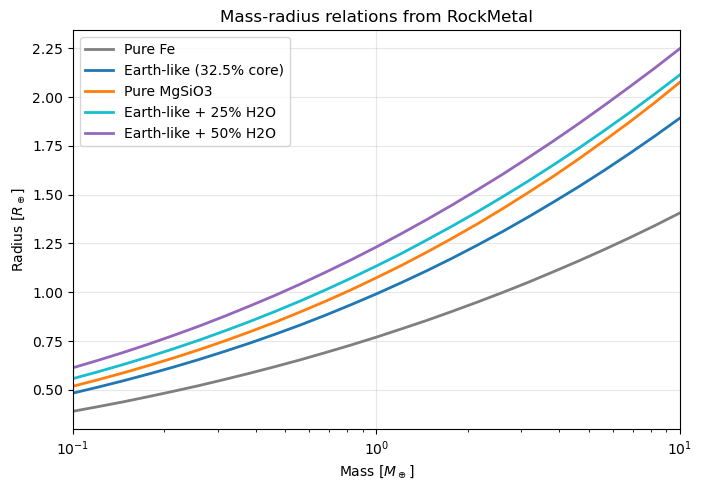

In [10]:
masses = np.logspace(-1, 1, 25)  # 0.1 to 10 Earth masses

compositions = [
    ("Pure Fe",                1.0,   0.0, "tab:gray"),
    ("Earth-like (32.5% core)", 0.325, 0.0, "tab:blue"),
    ("Pure MgSiO3",            0.0,   0.0, "tab:orange"),
    ("Earth-like + 25% H2O",   0.325, 0.25, "tab:cyan"),
    ("Earth-like + 50% H2O",   0.325, 0.50, "tab:purple"),
]

plt.figure(figsize=(7, 5))
for label, f_core, f_h2o, color in compositions:
    radii = [rock_metal(f_core, f_h2o, Mp) for Mp in masses]
    plt.plot(masses, radii, label=label, color=color, lw=2)

plt.xscale("log")
plt.xlabel("Mass [$M_\\oplus$]")
plt.ylabel("Radius [$R_\\oplus$]")
plt.title("Mass-radius relations from RockMetal")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(masses[0],masses[-1])
plt.show()


## Radius as a function of core mass fraction

At fixed total mass, sweeping the core fraction from 0 (all mantle) to 1
(all Fe) shows how much a planet shrinks as it becomes more iron-rich.


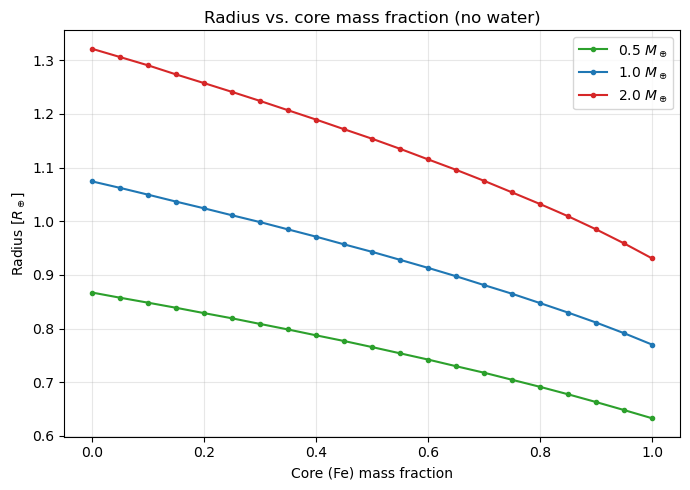

In [7]:
f_cores = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(7, 5))
for Mp, color in [(0.5, "tab:green"), (1.0, "tab:blue"), (2.0, "tab:red")]:
    radii = [rock_metal(fc, 0.0, Mp) for fc in f_cores]
    plt.plot(f_cores, radii, marker="o", ms=3, label=f"{Mp} $M_\\oplus$", color=color)

plt.xlabel("Core (Fe) mass fraction")
plt.ylabel("Radius [$R_\\oplus$]")
plt.title("Radius vs. core mass fraction (no water)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
